# Constant source (balance border)

The source represents the balance boundary for incoming flows.

<img src = "./model.svg" width=100px>

## Model equations

There are no model equations for the constant source. All variables of the output port are copied to the connected model by the waveform algorithm.

## Parameters

There are no parameters for the model.


## Implementation of the source model with constant values (ConstantSource)


In [ ]:
from simunetcore import Model
import numpy as np

# Model implementation for the Source
class ConstantSource(Model):
    def __init__(self, name=""):
        Model.__init__(self, name)

        # Model endpoint
        self.site = "local"
        self.threadsafe = True
                 
    def compute(self, *args, **kwargs):
        for var_id in self.vars:
            # Create result array
            y = np.full(len(self.t), self.get_var(var_id)[-1]).tolist()
            # Set results
            self.set_var(var_id, y)

## Computation of the source model with constant values (ConstantSource)

In [2]:
import numpy as np

# Create model
In_1 = ConstantSource("In_1")

# Setup vars and output port
In_1.vars = {
    "A" : {"description": "Var A", "unit": ""},
    "B" : {"description": "Var B", "unit": ""}
}
In_1.y["y_1"] = {
    "type": "source", 
    "description": "source", 
    "vars": ["A", "B"]
}

# Setup integration time
t_start = 0.0
t_end = 300.0
numpoints = 21
In_1.set_t(np.linspace(t_start, t_end, numpoints))

# Setup imput vector
A = 800
B = 300
y_1 = [[A], [B]]
In_1.set_y("y_1", y_1)

# Test the compute method
In_1.compute()

## Results

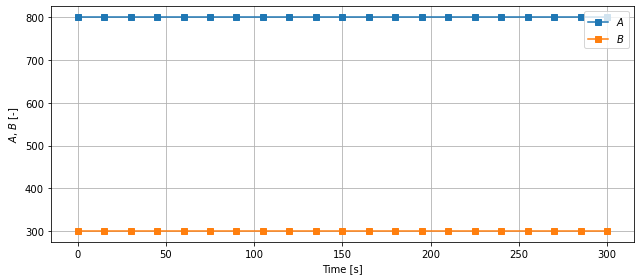

In [3]:
import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(9,4))

# Plot values
plt.plot(In_1.get_t(), In_1.get_var("A", In_1.get_t()), "-s", label="$A$")
plt.plot(In_1.get_t(), In_1.get_var("B", In_1.get_t()), "-s", label="$B$")

# Axis labels
plt.ylabel("$A$, $B$ [-]")
plt.xlabel('Time [s]')

# Show grid
plt.grid(True)

# Show legend
plt.legend(loc=1)   

# Layout and show
plt.tight_layout()
plt.show()